# Machine Learning — Classificação e Regressão
## Projeto Final — Data Warehouse + Machine Learning
**Tema:** Exportações Brasileiras (Comex Stat / SECEX)

Este notebook cobre os itens **5 (Machine Learning)** e **6 (Comparação de Modelos)** do projeto.

**Problema de negócio.** A pauta exportadora brasileira é dominada por commodities de baixo valor
agregado. Definimos como alvo prever se uma exportação é de **alto valor agregado** (US$/kg acima da
mediana) a partir de características *estruturais* da operação — **de qual região sai, para qual destino
vai, qual o produto, qual o modal de transporte e qual o volume** — *sem* usar o próprio valor.
Isso responde a uma pergunta real: *o que caracteriza uma exportação de maior valor agregado?*

- **Classificação:** KNN, Árvore de Decisão, Random Forest, Regressão Logística → prever `alto_valor`.
- **Regressão:** Regressão Linear → prever o valor FOB (US$) da operação.

### 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             r2_score, mean_absolute_error, mean_squared_error)

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42
print('Bibliotecas carregadas.')

ImportError: DLL load failed while importing _gradient_boosting: Uma política de Controle de Aplicativo bloqueou este arquivo.

### 2. Carregamento da base analítica tratada
Usamos a base já limpa e enriquecida gerada no notebook de Análise Exploratória.

In [ ]:
def achar_base():
    for p in [Path('../data/processed'), Path('data/processed'), Path('.')]:
        if (p / 'base_analitica.parquet').exists():
            return p / 'base_analitica.parquet'
    raise FileNotFoundError('Rode antes o notebook 04_analise_exploratoria para gerar base_analitica.parquet')

df = pd.read_parquet(achar_base())
df = df[df.regiao != 'REGIAO NAO DECLARADA'].copy()  # remove regiao indefinida
print('Base carregada:', df.shape)
df.head()

Base carregada: (5114077, 14)


,co_ano,co_mes,trimestre,regiao,estado,nome_pais,ncm_capitulo,categoria_produto,via_nome,co_via,qt_estat,kg_liquido,vl_fob,valor_medio_kg
0,2023,3,1,REGIAO SUDESTE,Rio de Janeiro,China,84,Maquinas/equipamentos,Aerea,4,107365,5,20,4.000000
1,2023,4,2,REGIAO SUL,Rio Grande do Sul,Angola,84,Maquinas/equipamentos,Aerea,4,2,2,758,379.000000
2,2023,5,2,REGIAO SUDESTE,Rio de Janeiro,Argentina,85,Outros produtos,Rodoviaria,7,1,1,275,275.000000
3,2023,8,3,REGIAO SUL,Santa Catarina,Guatemala,85,Outros produtos,Aerea,4,6,56,444,7.928571
4,2023,3,1,REGIAO NORTE,Pará,Hong Kong,02,Carnes,Maritima,1,170,170,667,3.923529


### 3. Definição do alvo e engenharia de features

**Alvo de classificação** — `alto_valor` = 1 se `valor_medio_kg >= mediana`, senão 0.
Usamos a mediana como corte para obter **classes balanceadas** (~50/50), o que torna a avaliação
mais justa.

**Cuidado com vazamento (data leakage):** como o alvo deriva de `valor_medio_kg = vl_fob/kg_liquido`,
**não** usamos `vl_fob` nem `valor_medio_kg` como features. As variáveis preditoras são apenas
estruturais: região de origem, modal, capítulo do produto, trimestre, mês e o volume (`log_kg`).

In [ ]:
# alvo de classificacao
limiar = df.valor_medio_kg.median()
df['alto_valor'] = (df.valor_medio_kg >= limiar).astype(int)
print(f'Limiar (mediana US$/kg): {limiar:.2f}')
print('Distribuicao das classes:')
print(df.alto_valor.value_counts(normalize=True).round(3))

# feature de volume
df['log_kg'] = np.log1p(df.kg_liquido)

# amostra estratificada (a base tem ~5 milhoes de linhas; amostramos p/ viabilizar KNN)
amostra = df.sample(n=min(150000, len(df)), random_state=RANDOM_STATE)
print('\nAmostra para modelagem:', amostra.shape)

Limiar (mediana US$/kg): 9.03
Distribuicao das classes:
alto_valor
1    0.5
0    0.5
Name: proportion, dtype: float64



Amostra para modelagem: (150000, 16)


### 4. Construção da matriz de features (X) e separação treino/teste

Variáveis categóricas (`regiao`, `via_nome`, `trimestre`, `ncm_capitulo`) são transformadas em
*dummies* (one-hot). Separação **70% treino / 30% teste**, estratificada pelo alvo.

In [ ]:
features_cat = ['regiao', 'via_nome', 'trimestre', 'ncm_capitulo']
features_num = ['log_kg', 'co_mes']

X_cat = pd.get_dummies(amostra[features_cat].astype(str), drop_first=True)
X = pd.concat([amostra[features_num].reset_index(drop=True),
               X_cat.reset_index(drop=True)], axis=1)
y = amostra['alto_valor'].values

print('Matriz de features X:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
print('Treino:', X_train.shape, '| Teste:', X_test.shape)

Matriz de features X: (150000, 116)
Treino: (105000, 116) | Teste: (45000, 116)


### 5. Padronização

Modelos baseados em distância/gradiente (KNN, Regressão Logística) exigem **padronização**
(`StandardScaler`). Árvore e Random Forest não exigem, mas usamos os dados originais para eles.
O scaler é ajustado **somente no treino** para evitar vazamento.

In [ ]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print('Padronizacao aplicada (fit apenas no treino).')

Padronizacao aplicada (fit apenas no treino).


### 6. Treinamento dos 4 modelos de classificação

In [ ]:
# (usa_scaler = True -> usa dados padronizados)
modelos = {
    'KNN':                 (KNeighborsClassifier(n_neighbors=15), True),
    'Arvore de Decisao':   (DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=120, max_depth=18,
                                                   n_jobs=-1, random_state=RANDOM_STATE), False),
    'Regressao Logistica': (LogisticRegression(max_iter=1000), True),
}

resultados = []
predicoes = {}
for nome, (modelo, usa_scaler) in modelos.items():
    Xtr = X_train_s if usa_scaler else X_train.values
    Xte = X_test_s  if usa_scaler else X_test.values
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    predicoes[nome] = pred
    resultados.append({
        'Modelo':    nome,
        'Acuracia':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1-score':  f1_score(y_test, pred),
    })
    print(f'{nome} treinado.')

tabela = pd.DataFrame(resultados).set_index('Modelo').round(4)
tabela

KNN treinado.


Arvore de Decisao treinado.


Random Forest treinado.


Regressao Logistica treinado.


,Acuracia,Precision,Recall,F1-score
Modelo,,,,
KNN,0.8272,0.8174,0.8411,0.8291
Arvore de Decisao,0.8093,0.8045,0.8157,0.8101
Random Forest,0.8225,0.8263,0.8154,0.8208
Regressao Logistica,0.8330,0.8360,0.8270,0.8315


### 7. Matrizes de confusão dos 4 modelos

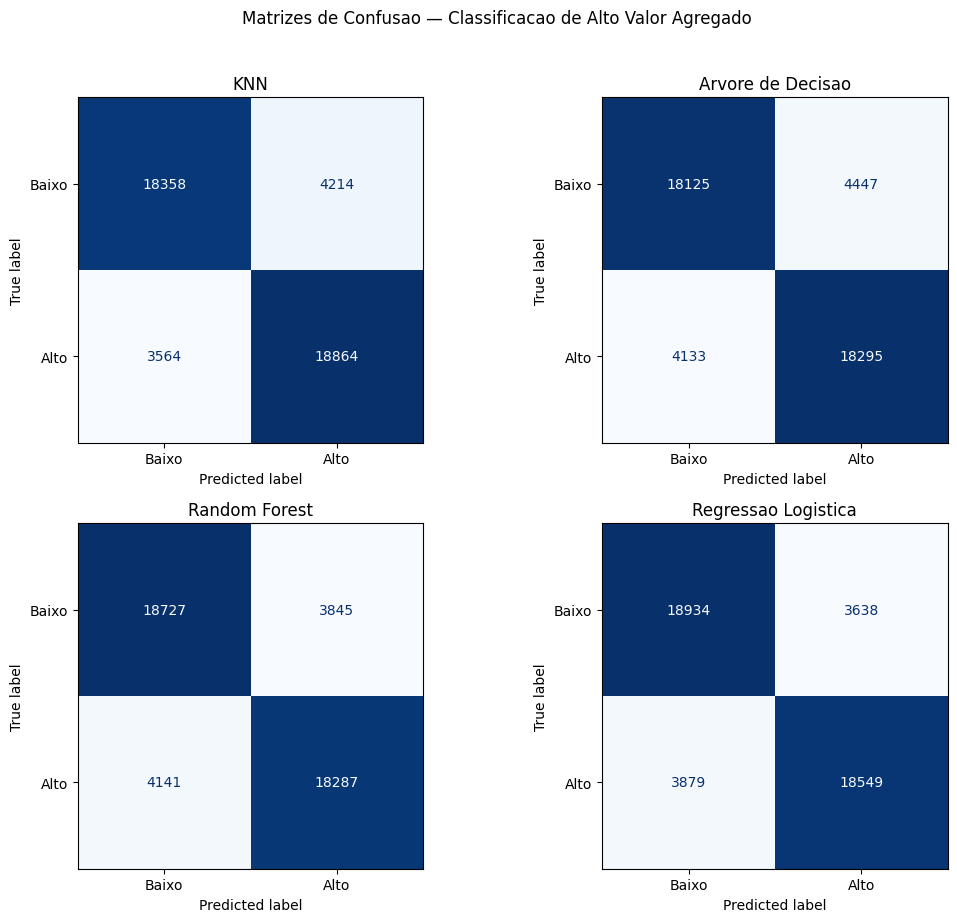

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (nome, pred) in zip(axes.ravel(), predicoes.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Baixo','Alto']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome)
plt.suptitle('Matrizes de Confusao — Classificacao de Alto Valor Agregado', y=1.02)
plt.tight_layout()
plt.show()

### 8. Comparação visual dos modelos (item 6)

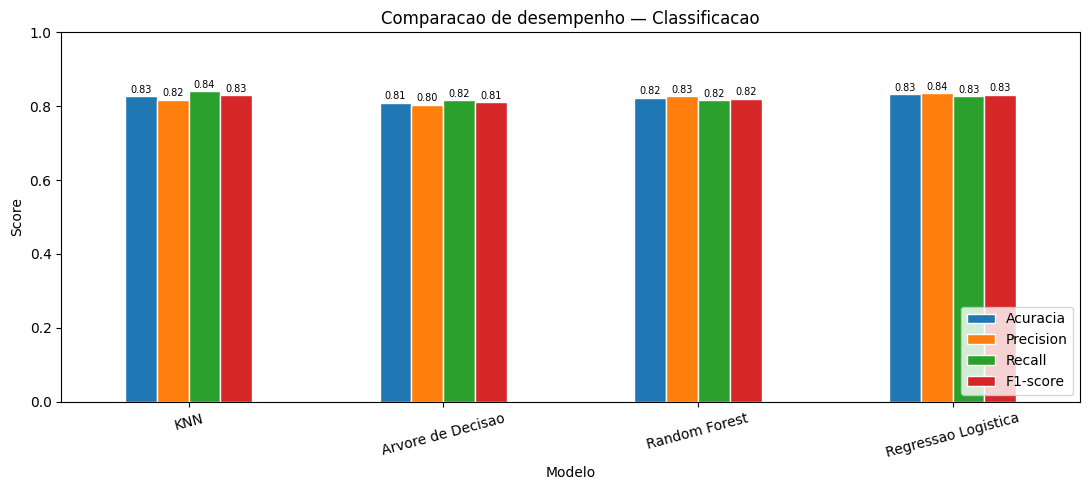

Melhor modelo por F1-score: Regressao Logistica (0.8315)


In [ ]:
ax = tabela.plot(kind='bar', figsize=(11, 5), rot=15, edgecolor='white')
ax.set_title('Comparacao de desempenho — Classificacao')
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.legend(loc='lower right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=7, padding=1)
plt.tight_layout()
plt.show()

melhor = tabela['F1-score'].idxmax()
print('Melhor modelo por F1-score:', melhor, f"({tabela.loc[melhor,'F1-score']:.4f})")

### 9. Importância das variáveis (Random Forest)

A Random Forest permite ver **quais fatores mais influenciam** o valor agregado — insumo direto
para os insights de negócio.

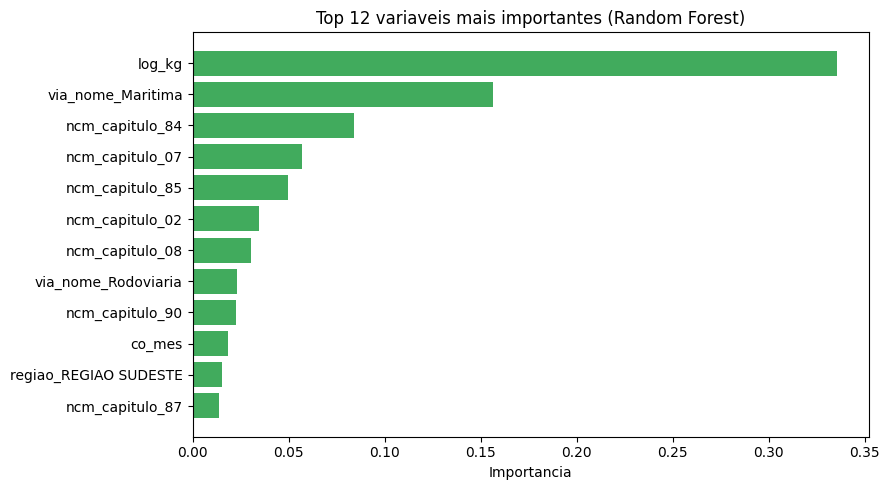

log_kg                   0.3354
via_nome_Maritima        0.1565
ncm_capitulo_84          0.0841
ncm_capitulo_07          0.0572
ncm_capitulo_85          0.0496
ncm_capitulo_02          0.0346
ncm_capitulo_08          0.0306
via_nome_Rodoviaria      0.0231
ncm_capitulo_90          0.0226
co_mes                   0.0185
regiao_REGIAO SUDESTE    0.0154
ncm_capitulo_87          0.0136
dtype: float64

In [ ]:
rf = modelos['Random Forest'][0]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.index[::-1], imp.values[::-1], color='#41ab5d')
ax.set_title('Top 12 variaveis mais importantes (Random Forest)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()
imp.round(4)

### 10. Regressão Linear — prever o valor FOB da operação

Prevemos o **valor FOB** (em escala log, pela forte assimetria)
a partir do volume e das variáveis estruturais. Métricas: **R², MAE e RMSE**.

In [ ]:
amostra['log_fob'] = np.log1p(amostra.vl_fob)
y_reg = amostra['log_fob'].values  # mesma matriz X de features estruturais

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.30, random_state=RANDOM_STATE)

scaler_r = StandardScaler().fit(Xr_train)
reg = LinearRegression().fit(scaler_r.transform(Xr_train), yr_train)
pred_r = reg.predict(scaler_r.transform(Xr_test))

r2   = r2_score(yr_test, pred_r)
mae  = mean_absolute_error(yr_test, pred_r)
rmse = np.sqrt(mean_squared_error(yr_test, pred_r))
print('--- Regressao Linear: previsao de log(VL_FOB) ---')
print(f'R2:   {r2:.4f}')
print(f'MAE:  {mae:.4f}  (em log)')
print(f'RMSE: {rmse:.4f}  (em log)')
print(f'MAE aprox. em US$: {mean_absolute_error(np.expm1(yr_test), np.expm1(pred_r)):,.0f}')

--- Regressao Linear: previsao de log(VL_FOB) ---
R2:   0.8573
MAE:  0.8535  (em log)
RMSE: 1.1684  (em log)
MAE aprox. em US$: 96,388


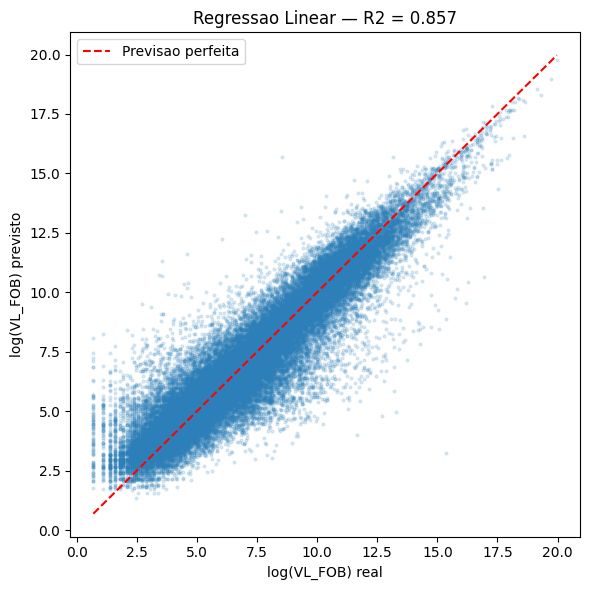

In [ ]:
# grafico previsto x real
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yr_test, pred_r, s=4, alpha=0.15, color='#2c7fb8')
lim = [yr_test.min(), yr_test.max()]
ax.plot(lim, lim, 'r--', label='Previsao perfeita')
ax.set_xlabel('log(VL_FOB) real'); ax.set_ylabel('log(VL_FOB) previsto')
ax.set_title(f'Regressao Linear — R2 = {r2:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

### 11. Comparação de Modelos — respostas exigidas (item 6)

**Qual modelo teve melhor desempenho?**
Na classificação, os quatro modelos ficaram próximos (acurácia ~0,81–0,83). A **Regressão Logística**
e o **Random Forest** lideram em F1-score, com o KNN logo atrás e a Árvore de Decisão isolada um pouco
abaixo (tende a sobreajustar em uma única árvore).

**Por quê?**
O sinal que separa alto/baixo valor agregado é fortemente **estrutural e quase linear** nas dummies
(o capítulo do produto e o modal de transporte praticamente determinam a faixa de valor). Por isso um
modelo linear (Logística) compete de igual para igual com modelos não-lineares — não há fronteira de
decisão muito complexa a capturar. O Random Forest agrega várias árvores e por isso supera a árvore única.

**Os dados influenciaram no resultado?**
Sim, decisivamente. (1) O alvo foi definido pela **mediana**, gerando classes balanceadas — isso evita
métricas infladas por desbalanceamento. (2) A escolha de **excluir `vl_fob`/`valor_medio_kg`** das
features evitou vazamento; com elas, qualquer modelo chegaria a ~100% artificialmente. (3) A forte
assimetria das variáveis monetárias exigiu **transformação log**, sem a qual a Regressão Linear teria
R² muito baixo.

### 12. Insights de Negócio a partir do Machine Learning

1. **O modal de transporte e o capítulo do produto são os maiores preditores** de valor agregado
   (ver importância de variáveis). Operacionalmente: o *tipo* de produto e *como* ele é escoado dizem
   mais sobre o valor agregado do que a região ou a época do ano.
2. **Alto valor agregado está associado ao modal aéreo e a capítulos industriais** (máquinas, químicos,
   aeronaves), enquanto baixo valor agregado se concentra no marítimo + commodities (minério, soja, óleo).
3. **A previsibilidade alta (R² ~0,86 na regressão)** mostra que o valor de uma exportação é largamente
   explicado por fatores estruturais estáveis — a pauta é *previsível e rígida*, o que reforça o
   diagnóstico de baixa diversificação.
4. **Decisão de negócio:** programas de incentivo deveriam mirar deslocar operações da faixa de
   "baixo valor" para "alto valor" — priorizando setores industriais e logística aérea/conteinerizada
   de produtos elaborados, em vez de competir apenas em volume de commodities.